<a href="https://colab.research.google.com/github/amitsingh6261/Machine_learning/blob/main/LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  record_id  age     sex   bmi  children smoker region  charges
0      I001   25  female  19.3         3     no  south     8520
1      I002   32    male  20.6         1     no   east     9080
2      I003   39  female  21.9         4     no   west    11740
3      I004   46    male  23.2         2     no  north    12300
4      I005   53  female  24.5         0     no  south    12860
(60, 8)
record_id     object
age            int64
sex           object
bmi          float64
children       int64
smoker        object
region        object
charges        int64
dtype: object
record_id    0
age          0
sex          0
bmi          0
children     0
smoker       0
region       0
charges      0
dtype: int64
MAE : 662.8798393716197
MSE : 557046.1080091207
RMSE: 746.3552157043727
R2 Score: 0.9845049566028297


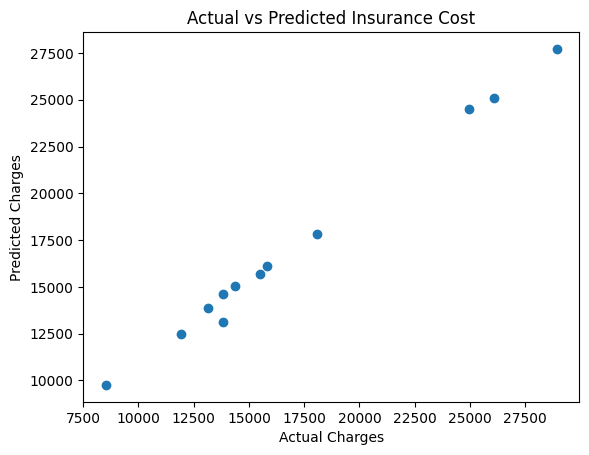

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# 1. Load dataset
df = pd.read_csv("/content/insurance_cost_course_data.csv")
# 2. Check data
print(df.head())
print(df.shape)
print(df.dtypes)
print(df.isna().sum())


# 3. Target column
# maan lo insurance cost ki column "charges" hai
X = df.drop("charges", axis=1)
y = df["charges"]


# 4. Categorical and numerical columns
numeric_columns = X.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = X.select_dtypes(include=["object"]).columns


# 5. Numerical data pipeline
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# 6. Categorical data pipeline
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


# 7. Combine both pipelines
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_columns),
    ("categorical", categorical_pipeline, categorical_columns)
])


# 8. Complete model pipeline
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])


# 9. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# 10. Train model
model.fit(X_train, y_train)


# 11. Prediction
prediction = model.predict(X_test)


# 12. Evaluation
mae = mean_absolute_error(y_test, prediction)
mse = mean_squared_error(y_test, prediction)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, prediction)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


# 13. Actual vs Predicted graph
plt.scatter(y_test, prediction)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Cost")
plt.show()